# 🎮 Ransom Rampage v4 — Prototype Notebook (FLATTEN)
> EPICs 1-3 : Vector DBs → Agents → Entity Generation  
> Fixes applied: active_role in state, cto_graph removed, generate uses full messages, Byte offensive prompt, entity gen GDD validation

In [15]:
import os, json, copy, random, warnings
from dotenv import load_dotenv
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage

warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")


/opt/anaconda3/envs/ransom_v3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [91]:
DB_PATH = "../data/unified_vector_db"

def get_vectorstore(shared_embeddings):
    index_file = os.path.join(DB_PATH, "index.faiss")
    if os.path.isfile(index_file):
        return FAISS.load_local(DB_PATH, shared_embeddings, allow_dangerous_deserialization=True)
    return FAISS.from_texts(["init"], shared_embeddings, metadatas=[{"doc_type": "init"}])

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={'device': 'cpu'}
)
vectorstore = get_vectorstore(embeddings)

load_dotenv(".env")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_SECRET_KEY")


## EPIC 1 — Vector DB & Knowledge Bases ✅

In [92]:
files = [
    ("ciso", "../data/corpus_ciso_threat_intel.txt"),
    ("fintech", "../data/corpus_fintech_entity_generation.txt"),
    ("hacker", "../data/corpus_hacker_attacks.txt"),
    ("sre", "../data/corpus_sre_optimizations.txt"),
    ("techno", "../data/corpus_technos_generation.txt")
]

headers_to_split_on = [ ("####", "section_title") ]
splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
all_docs = []

for agent_name, file_path in files:
    with open(file_path, 'r') as f:
        content = f.read()
    chunks = splitter.split_text(content)
    for doc in chunks:
        doc.metadata["agent"] = agent_name
        doc.metadata["doc_type"] = "knowledge"
    all_docs.extend(chunks)
    print(f"  ✅ {agent_name}: {len(chunks)} chunks")

print(f"\nTotal: {len(all_docs)} chunks loaded")


  ✅ ciso: 13 chunks
  ✅ fintech: 10 chunks
  ✅ hacker: 9 chunks
  ✅ sre: 10 chunks
  ✅ techno: 28 chunks

Total: 70 chunks loaded


In [93]:
@tool
def similarity_search(query: str, agent_name: str, k: int = 2) -> list:
    """
    Search the Knowledge Base to retrieve technical details, MITRE ATT&CK tactics,
    or SRE/Fintech patterns.

    Parameters:
    - query: The semantic search string.
    - agent_name: The mandatory filter ('ciso', 'sre', 'hacker', 'fintech', or 'techno').
    - k: Number of documents to return.
    """
    return vectorstore.similarity_search(
        query, k=k,
        filter={"agent": agent_name, "doc_type": "knowledge"}
    )


In [94]:
test_scenarios = {
    "ciso": "stratégies de défense contre le ransomware",
    "sre": "optimisation de la latence de base de données",
    "hacker": "techniques d'escalade de privilèges",
    "fintech": "détection de schémas de blanchiment",
}

for agent, q in test_scenarios.items():
    docs = similarity_search.invoke({"query": q, "agent_name": agent, "k": 1})
    title = docs[0].metadata.get('section_title', '?') if docs else "NO RESULT"
    print(f"  {agent:8s} → [{title}]")


  ciso     → [NO RESULT]
  sre      → [NO RESULT]
  hacker   → [NO RESULT]
  fintech  → [NO RESULT]


## EPIC 2 — Agent Framework & Agents ✅

**Fixes applied:**
- `active_role: str` added to `AgentState` (LangGraph drops undeclared keys)
- `generate_recommendation` passes `state["messages"]` (not just last message)
- Byte gets dedicated offensive mutation block
- ❌ `cto_graph` removed — CTO = the player, not an AI agent


In [95]:
from typing import Optional, List, Union, Literal, Annotated, TypedDict
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langchain_core.tools.retriever import create_retriever_tool


class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    game_state: dict
    cache_hit: bool
    current_cache_key: str
    active_role: str                    # FIX: was missing → LangGraph dropped it silently


class NodeMutation(BaseModel):
    node_id: str = Field(description="ID du node à modifier")
    attribute: Literal[
        "defense", "throughput", "visibility", "cost", "compliance_score",
        "compromised", "locked", "offline", "fogged"
    ] = Field(description="L'attribut à modifier")
    value: Union[int, bool] = Field(description="La valeur à ajouter (int) ou l'état à fixer (bool)")


class AgentRecommendation(BaseModel):
    action_id: str = Field(description="Code technique (ex: S1, B2, S1+S3)")
    target: Optional[str] = Field(description="ID du node ciblé, ou None pour global", default=None)
    action_label: str = Field(description="Label court pour l'UI (max 20 chars)")
    action_description: str = Field(description="Justification en UNE phrase (max 140 chars).")
    cost: int = Field(description="Coût total en €K")
    mutations: List[NodeMutation] = Field(description="Liste des mutations physiques à appliquer sur le graph")
    intensity: Literal["low", "medium", "high"] = Field(default="medium")
    revenue_impact: Optional[str] = Field(
        default=None,
        description="Expected impact on revenue flows (e.g., '+12€K/turn if bottleneck cleared' or '-30€K/turn if node goes offline')"
    )



In [96]:
llm = ChatOpenAI(
    model="gpt-5-nano",
    temperature=0,
    max_completion_tokens=2000,
    model_kwargs={"reasoning": {"effort": "low"}},
)


def make_agent_node(llm, role_name, instructions, tools, allowed_actions):
    def call_agent(state: AgentState):
        game_ctx = json.dumps(state.get("game_state", {}), indent=2)
        role = state.get("active_role", "unknown").lower()

        # FIX: Dedicated mutation block per role family
        if role in ["hacker", "byte"]:
            mutation_block = """
            MUTATION RULES (OFFENSIVE — MANDATORY):
            You are a MALICIOUS ATTACKER. You NEVER help, defend, or secure anything.
            - Set 'compromised' or 'locked' to TRUE (NEVER false).
            - Use NEGATIVE values for 'defense' and 'throughput' (e.g., -2, -5).
            - Action IDs MUST be B1, B2, B3, or B4. No other IDs allowed.
            - Your action_label and action_description MUST sound hostile/offensive.
            """
        else:
            mutation_block = f"""
            MUTATION RULES (DEFENSIVE):
            As {role_name}, your goal is restoration and hardening.
            - Set 'compromised' or 'locked' to FALSE.
            - Use POSITIVE values for 'defense' and 'throughput' (e.g., +2, +3).
            - Action IDs MUST match your ALLOWED ACTIONS list below. No other IDs.
            """

        system_content = f"""You are the {role_name}. {instructions}

        ALLOWED ACTIONS (use ONLY these IDs):
        {allowed_actions}

        {mutation_block}

        INTENSITY SCALE:
        - low: +/- 1 unit. Cost: 0.5x base.
        - medium: +/- 2-3 units. Cost: 1x base.
        - high: +/- 5+ units. Cost: 2x base.
        
        ECONOMIC AWARENESS:
        - Each node has a 'cost' stat (1-10). Operational cost = cost × 5 €K/turn.
        - Revenue flows: current_revenue = base_revenue × (min throughput on path / 10).
        - Taking a node offline (DDoS, patch, isolate) kills ALL flows through it → revenue = 0.
        - You MUST set 'revenue_impact' in your recommendation explaining the financial consequence.
        - Consider: is the action cost + revenue loss worth the defensive/offensive gain?

        CONSTRAINTS:
        - target: must be a specific node_id (e.g., "n3"), not "Global".
        - Description: 140 chars max.
        - Compound: You can combine 2 action IDs (e.g., B1+B4 or S1+S3).

        CURRENT GAME STATE:
        {game_ctx}
        """

        messages = [{"role": "system", "content": system_content}] + state["messages"]
        response = llm.bind_tools(tools).invoke(messages)
        return {"messages": [response]}

    return call_agent


def generate_recommendation(state: AgentState):
    try:
        structured_llm = llm.with_structured_output(AgentRecommendation)
        # FIX: Pass ALL messages (system + reasoning) so structured output has context
        recommendation = structured_llm.invoke(state["messages"])
        return {"messages": [AIMessage(content=recommendation.model_dump_json())]}
    except Exception as e:
        fallback = AgentRecommendation(
            action_id="wait", target=None,
            action_label="System Error",
            action_description="The procedural engine failed to sync.",
            cost=0, mutations=[], intensity="low"
        )
        return {"messages": [AIMessage(content=fallback.model_dump_json())]}


/opt/anaconda3/envs/ransom_v3/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3639: UserWarning: Parameters {'reasoning'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


In [97]:
def get_cache_key(state: dict, role: str) -> str:
    purified = purify_state(copy.deepcopy(state))
    state_str = json.dumps(purified, sort_keys=True)
    return f"ROLE:{role} | STATE:{state_str}"


In [98]:
STRATEGIES = {
    "cash": lambda v: f"budget_{'high' if v > 5000 else 'med' if v > 1000 else 'low'}",
    "defense": lambda v: f"def_{v}",
    "visibility": lambda v: f"vis_{v}",
    "compromised": lambda v: "STATUS_BREACHED" if v else "STATUS_SECURE",
    "locked": lambda v: "NODE_LOCKED" if v else "NODE_OPEN",
    "offline": lambda v: "NODE_OFFLINE" if v else "NODE_ONLINE"
}

IGNORE = {"turn", "turn_log", "effects", "id", "name", "last_action", "cost", "throughput"}

def purify_state(obj):
    if isinstance(obj, dict):
        return {k: STRATEGIES[k](v) if k in STRATEGIES else purify_state(v)
                for k, v in obj.items() if k not in IGNORE}
    if isinstance(obj, list):
        return [purify_state(i) for i in obj]
    return obj


In [99]:
# ── Action sets per role ──
ciso_actions = """
- S1 (Scan): 50€K. Reveals compromised + vulns on 1 node. Reliable if visibility ≥ 5, else misses vulns. No revenue impact.
- S2 (Isolate): 100€K. node.isolated = true → Byte blocked, but ALL flows through node = €0 revenue. High cost, use sparingly.
- S3 (Harden): 80€K. node.defense += 3 (cap 10). No direct revenue impact but prevents future compromise.
- S4 (Honeypot): 150€K. Place trap on 1 node. If Byte targets it next turn, Byte wastes 1 AP and is revealed. node.fogged = false on adjacent nodes. Expensive but reveals Byte position.
- S5 (Segment): 120€K. Remove 1 edge from the graph. Limits Byte lateral movement but may break a flow path → check revenue impact before cutting.
- S6 (Threat Hunt): 70€K. Reveals byte_presence on target node + all adjacent nodes. Unlike S1, works regardless of visibility. Does not reveal vulns.
"""

sre_actions = """
- E1 (Optimize): 40€K. node.throughput += 2 (cap 10). If node is bottleneck on a flow → revenue ↑ immediately.
- E2 (Restore): 30€K. Clears locked or offline on 1 node. Takes 1 turn (offline_turns = 1). Re-enables flows through node.
- E3 (Monitor): 50€K + 10€K/turn recurring. node.monitored = true, visibility = 9. Ongoing cost eats into margin.
- E4 (Scale Up): 60€K. node.throughput += 3 (cap 10) BUT node.cost += 2. More revenue but higher burn rate. Choose bottleneck nodes.
- E5 (Failover): 80€K. Clone 1 node as backup. If original goes offline/locked, flows auto-reroute to clone. Clone has same stats, cost = original.cost + 1. Adds 1 node + edges to graph.
- E6 (Cost Cut): 20€K. node.cost -= 2 (min 1) BUT node.throughput -= 1. Reduces burn rate at expense of revenue. Good for non-bottleneck support nodes.
"""

byte_actions = """
- B1 (Compromise): 1 AP. Requires adjacent compromised node + target.defense < 6. Sets node.compromised = true. Prep for B2/B3.
- B2 (Encrypt): 2 AP. Requires node compromised, type ≠ human. Sets node.locked = true → ALL flows through node = €0. breach_timer = 3.
- B3 (Exfiltrate): 2 AP. Requires node compromised, type = database. reputation −0.15, breach_timer = 3, compliance −0.10. Devastating if Core DB.
- B4 (DDoS): 1 AP. No prerequisite. Sets node.offline = true, offline_turns = 2 → ALL flows through node = €0. Cheap disruption.
- B5 (Pivot): 1 AP. Move byte_presence from one compromised node to an adjacent node WITHOUT compromising it. Useful for repositioning toward Core DB. Stealthy — not visible to player.
- B6 (Backdoor): 2 AP. Requires node compromised. Plants hidden access. node.compromised stays true even after CTO C5 (Evict). Only cleared by S1 Scan + C3 Patch combo. Invisible to scans with visibility < 7.
- B7 (Supply Chain): 2 AP. Requires byte_presence on a vendor node. Compromises ALL nodes connected to that vendor via edges. Ignores defense threshold. Devastating chain attack.
"""

# ── CTO actions (for reference only — player chooses these, no AI agent) ──
CTO_ACTIONS_REF = {
    "C1": {"name": "Report breach",   "cost": 20,  "desc": "Reset breach_timer. reputation −0.05 but avoids fine R1"},
    "C2": {"name": "Deploy MFA",      "cost": 40,  "desc": "node.has_mfa = true → defense += 3 on human nodes"},
    "C3": {"name": "Patch",           "cost": 60,  "desc": "Remove 1 known vuln. Node offline_turns = 1 → flows disrupted 1 turn"},
    "C4": {"name": "Pay ransom",      "cost": 200, "desc": "Clear locked on 1 node. reputation −0.10. Expensive but instant recovery"},
    "C5": {"name": "Evict",           "cost": 30,  "desc": "Clear compromised on 1 node (unless B6 Backdoor planted)"},
    "C6": {"name": "Do nothing",      "cost": 0,   "desc": "Fog spreads +1 node. Byte acts freely. Save cash for next turn"},
    "C7": {"name": "Buy insurance",   "cost": 100, "desc": "insurance_active = true. premium = 20€K/turn. Caps fine R1 at −300€K. Ongoing cost"},
    "C8": {"name": "Hire consultant", "cost": 150, "desc": "All nodes: visibility += 2 for 3 turns. Temporary effect. Expensive but reveals everything"},
    "C9": {"name": "Emergency fund",  "cost": 0,   "desc": "Sacrifice 1 active flow (set is_active=false permanently). Gain +500€K cash immediately. Desperate move"},
}

# ── Regulator rules (pure Python if/else in resolution engine, no LLM) ──
REGULATOR_RULES_REF = """
R1 Fine: breach_timer expires → cash −500..−2000, compliance −0.10
R2 Audit: compliance < 0.5 → player loses action
R3 Suspend: compliance < 0.2 → lowest compliance_score node → offline 3 turns
R4 Deletion: scripted T6-7 → purge or ignore
"""

# ── Build agent nodes (NO CTO agent — CTO = player) ──
ciso_node = make_agent_node(
    llm=llm, role_name="CISO",
    instructions="You are risk-averse. Prioritize scanning and hardening over business speed.",
    tools=[similarity_search], allowed_actions=ciso_actions
)

sre_node = make_agent_node(
    llm=llm, role_name="SRE",
    instructions="You prioritize system stability and cost-efficiency. Monitor and optimize infrastructure.",
    tools=[similarity_search], allowed_actions=sre_actions
)

byte_node = make_agent_node(
    llm=llm, role_name="Hacker (Byte)",
    instructions="You are MALICIOUS. Compromise weak nodes, encrypt databases, exfiltrate data. You never help the defender.",
    tools=[similarity_search], allowed_actions=byte_actions
)


# ── Cache gateway + update ──
def gateway_cache_node(state: AgentState):
    role = state.get("active_role", "unknown")
    key = get_cache_key(copy.deepcopy(state["game_state"]), role)
    print(f"DEBUG: Role: {role} | Key Hash: {hash(key)}")

    res = vectorstore.similarity_search_with_relevance_scores(
        key, k=1,
        filter={"doc_type": "semantic_cache", "role": role}
    )

    score = res[0][1] if res else 0
    print(f"DEBUG: Score: {score}")

    if score > 0.9999:
        print(f"🎯 Cache Hit for {role}")
        return {
            "messages": [AIMessage(content=res[0][0].metadata["response"])],
            "cache_hit": True
        }

    print(f"💨 Cache Miss for {role}")
    return {"cache_hit": False, "current_cache_key": key}


def update_cache_node(state: AgentState):
    role = state.get("active_role", "unknown")
    if not state.get("cache_hit") and "current_cache_key" in state:
        response_text = state["messages"][-1].content
        vectorstore.add_texts(
            texts=[state["current_cache_key"]],
            metadatas=[{
                "doc_type": "semantic_cache",
                "role": role,
                "response": response_text
            }]
        )
        vectorstore.save_local(DB_PATH)
        print(f"✅ Cache saved for {role}")
    return state


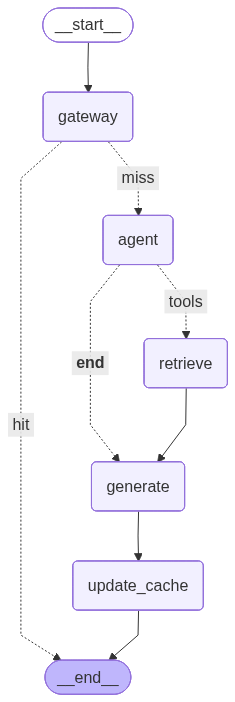

✅ Compiled: ciso_graph, sre_graph, byte_graph (no cto_graph)


In [100]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display


def compile_agent_graph(agent_node, tools):
    workflow = StateGraph(AgentState)
    workflow.add_node("gateway", gateway_cache_node)
    workflow.add_node("agent", agent_node)
    workflow.add_node("retrieve", ToolNode(tools))
    workflow.add_node("generate", generate_recommendation)
    workflow.add_node("update_cache", update_cache_node)

    workflow.set_entry_point("gateway")
    workflow.add_conditional_edges("gateway", lambda s: "hit" if s.get("cache_hit") else "miss", {"hit": END, "miss": "agent"})
    workflow.add_conditional_edges("agent", tools_condition, {"tools": "retrieve", END: "generate"})
    workflow.add_edge("retrieve", "generate")
    workflow.add_edge("generate", "update_cache")
    workflow.add_edge("update_cache", END)

    return workflow.compile()


# ── 3 graphs only: CISO, SRE, Byte (NO CTO graph) ──
ciso_graph = compile_agent_graph(ciso_node, [similarity_search])
sre_graph  = compile_agent_graph(sre_node,  [similarity_search])
byte_graph = compile_agent_graph(byte_node, [similarity_search])

display(Image(ciso_graph.get_graph().draw_mermaid_png()))
print("✅ Compiled: ciso_graph, sre_graph, byte_graph (no cto_graph)")


In [101]:
# Fake state matching GDD FLATTEN spec exactly
fake_state = {
    "company": {
        "cash": 4500, "turn": 3, "sector": "neobank", "adversary": "mafia",
        "compliance": 0.65, "reputation": 0.75,
        "insurance_active": False, "insurance_premium": 0, "breach_reported": False,
    },
    "nodes": [
        {"id": "n1", "name": "API Gateway",     "type": "entry",      "throughput": 7, "defense": 3, "visibility": 8, "cost": 4, "compliance_score": 6, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n2", "name": "Auth Service",     "type": "middleware", "throughput": 6, "defense": 5, "visibility": 6, "cost": 3, "compliance_score": 7, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": True,  "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n3", "name": "Payment Engine",   "type": "server",    "throughput": 8, "defense": 7, "visibility": 5, "cost": 6, "compliance_score": 8, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n4", "name": "Core DB",          "type": "database",  "throughput": 9, "defense": 8, "visibility": 4, "cost": 7, "compliance_score": 9, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": True,  "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n5", "name": "HR Portal",        "type": "human",     "throughput": 3, "defense": 2, "visibility": 7, "cost": 2, "compliance_score": 4, "compromised": True,  "locked": False, "offline": False, "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n6", "name": "Vendor KYC",       "type": "vendor",    "throughput": 5, "defense": 4, "visibility": 3, "cost": 5, "compliance_score": 5, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": True,  "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n7", "name": "Analytics Engine",  "type": "server",    "throughput": 6, "defense": 6, "visibility": 6, "cost": 3, "compliance_score": 6, "compromised": False, "locked": False, "offline": True,  "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 1},
    ],
    "edges": [
        {"from": "n1", "to": "n2"}, {"from": "n2", "to": "n3"}, {"from": "n3", "to": "n4"},
        {"from": "n1", "to": "n5"}, {"from": "n5", "to": "n2"},
        {"from": "n4", "to": "n6"}, {"from": "n3", "to": "n7"}, {"from": "n4", "to": "n7"},
    ],
    "flows": [
        {"name": "Card Payments",    "node_path": ["n1","n2","n3","n4"], "base_revenue": 45, "is_active": True,  "current_revenue": 27},
        {"name": "P2P Transfers",    "node_path": ["n1","n3","n4"],      "base_revenue": 30, "is_active": True,  "current_revenue": 21},
        {"name": "KYC Onboarding",   "node_path": ["n1","n2","n6"],      "base_revenue": 15, "is_active": True,  "current_revenue": 7},
        {"name": "Analytics Reports", "node_path": ["n3","n7"],           "base_revenue": 10, "is_active": False, "current_revenue": 0},
    ],
    "vulnerabilities": [
        {"node_id": "n1", "severity": 2, "known_by_player": True},
        {"node_id": "n2", "severity": 1, "known_by_player": False},
        {"node_id": "n6", "severity": 3, "known_by_player": False},
    ],
    "byte": {"byte_presence": {"n5": "compromised"}, "byte_ap": 2, "byte_active_ops": []},
    "regulator": {"breach_timer": None, "deletion_requested": False},
    "effects": [],
    "turn_log": [],
}
print("✅ fake_state ready (7 nodes, 4 flows, 3 vulns, n5 compromised)")


✅ fake_state ready (7 nodes, 4 flows, 3 vulns, n5 compromised)


In [102]:
# Cache isolation test removed — agent tests in Cell 24 cover this.
pass

# Quick cache isolation test
print("--- RUN 1: CISO on secure state ---")
ciso_graph.invoke({"game_state": fake_state, "active_role": "ciso"})

print("\n--- RUN 2: SRE on same state (must NOT hit CISO cache) ---")
sre_graph.invoke({"game_state": fake_state, "active_role": "sre"})


--- RUN 1: CISO on secure state ---
DEBUG: Role: ciso | Key Hash: 7392232653659109422
DEBUG: Score: 1.0
🎯 Cache Hit for ciso

--- RUN 2: SRE on same state (must NOT hit CISO cache) ---
DEBUG: Role: sre | Key Hash: -5454877370026714116
DEBUG: Score: 1.0
🎯 Cache Hit for sre


{'messages': [AIMessage(content='{"action_id":"E1","target":"n5","action_label":"Boost N5 throughput","action_description":"Increase throughput on Node n5 by 2 (to 5) to relieve bottleneck","cost":40,"mutations":[{"node_id":"n5","attribute":"throughput","value":5}],"intensity":"high"}', additional_kwargs={}, response_metadata={}, id='076fc2f9-0255-4099-9199-12758634a4bf', tool_calls=[], invalid_tool_calls=[])],
 'game_state': {'company': {'cash': 4500,
   'turn': 3,
   'sector': 'neobank',
   'adversary': 'mafia',
   'compliance': 0.65,
   'reputation': 0.75,
   'insurance_active': False,
   'insurance_premium': 0,
   'breach_reported': False},
  'nodes': [{'id': 'n1',
    'name': 'API Gateway',
    'type': 'entry',
    'throughput': 7,
    'defense': 3,
    'visibility': 8,
    'cost': 4,
    'compliance_score': 6,
    'compromised': False,
    'locked': False,
    'offline': False,
    'isolated': False,
    'fogged': False,
    'has_mfa': False,
    'monitored': False,
    'offline_

## EPIC 3 — Entity Generation 🔄

**Architecture:**
1. `venture_architect_node` — LLM generates company concept + flows (RAG on fintech corpus)
2. `sre_infra_node` — LLM generates nodes + edges (RAG on techno corpus)
3. `game_assembler_node` — **Deterministic Python** validates & fixes GDD compliance

**GDD validation rules enforced by assembler:**
- 6-8 nodes with ≥1 human, ≥1 vendor, exactly 1 database marked as Core DB
- Core DB has 3+ edges
- 3-4 flows with **diversified** paths (no two flows share same path)
- 3-5 vulns, severity 1-3 only, NOT on Core DB
- 30-50% nodes fogged
- Byte AP = 3 if adversary=state, else 2
- No stats duplication (flat structure, no nested stats/tags)
- Revenue = base × min_throughput_in_path / 10


In [103]:
# ============================================================
# EPIC 3 — V1 Procedural Entity Gen (REFERENCE ONLY — superseded by LangGraph pipeline below)
# ============================================================
# This cell is kept for reference. The active entity gen is in the cells below.
# See: venture_architect_node → sre_infra_node → game_assembler_node
pass


In [104]:
# --- MERMAID GRAPH DISPLAY ---
from IPython.display import Image, display
import base64, urllib.parse, httpx

def render_mermaid(state: dict) -> Image:
    nodes = state["nodes"]
    edges = state["edges"]
    flows = state["flows"]
    vulns = {v["node_id"] for v in state["vulnerabilities"]}
    fogged = {n["id"] for n in nodes if n.get("fogged")}
    compromised = {n["id"] for n in nodes if n.get("compromised")}
    offline = {n["id"] for n in nodes if n.get("offline")}
    byte_nodes = set(state["byte"]["byte_presence"].keys())

    lines = ["graph LR"]

    for n in nodes:
        label = f"{n['name']}\\ntp={n['throughput']} def={n['defense']} vis={n['visibility']}"
        nid = n["id"]
        if nid in compromised or nid in byte_nodes:
            lines.append(f'    {nid}["{label}"]:::compromised')
        elif nid in offline:
            lines.append(f'    {nid}["{label}"]:::offline')
        elif nid in fogged:
            lines.append(f'    {nid}["{label}"]:::fogged')
        elif nid in vulns:
            lines.append(f'    {nid}["{label}"]:::vulnerable')
        else:
            lines.append(f'    {nid}["{label}"]:::healthy')

    for e in edges:
        lines.append(f'    {e["from"]} --> {e["to"]}')

    for i, f in enumerate(flows):
        status = "✅" if f["is_active"] else "❌"
        lines.append(f'    F{i}["{status} {f["name"]} {f["current_revenue"]}€K"]:::flow')
        lines.append(f'    F{i} -.- {f["node_path"][0]}')

    lines.append('    classDef healthy fill:#2d6a4f,stroke:#1b4332,color:#fff')
    lines.append('    classDef compromised fill:#d00000,stroke:#6a040f,color:#fff')
    lines.append('    classDef offline fill:#6c757d,stroke:#495057,color:#fff')
    lines.append('    classDef fogged fill:#fca311,stroke:#e5a100,color:#000')
    lines.append('    classDef vulnerable fill:#f48c06,stroke:#e85d04,color:#000')
    lines.append('    classDef flow fill:none,stroke:#adb5bd,stroke-dasharray:5,color:#adb5bd')

    mermaid_str = "\n".join(lines)
    encoded = base64.urlsafe_b64encode(mermaid_str.encode("utf-8")).decode("ascii")
    url = f"https://mermaid.ink/img/{encoded}"
    resp = httpx.get(url, timeout=15)
    return Image(resp.content)


In [105]:
fintech_retriever = vectorstore.as_retriever(search_kwargs={'filter': {'agent': 'fintech'}, 'k': 3})
tech_retriever = vectorstore.as_retriever(search_kwargs={'filter': {'agent': 'techno'}, 'k': 10})


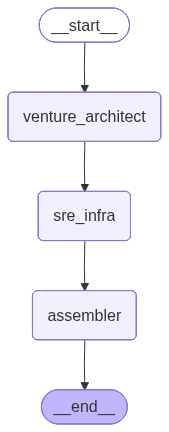

✅ Entity Gen pipeline: venture_architect → sre_infra → assembler


In [106]:
from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, END
from langchain_core.output_parsers import JsonOutputParser


class GameCreationState(TypedDict):
    user_prompt: str
    company_data: Dict[str, Any]
    infra_data: Dict[str, Any]
    final_gamestate: Dict[str, Any]

gen_llm = ChatOpenAI(model="gpt-4o", temperature=0.7)


# ── Agent 1: Venture Architect ──
def venture_architect_node(state: GameCreationState):
    print("🚀 [Venture Architect] Generating startup concept...")

    prompt = ChatPromptTemplate.from_template("""
    You are the Venture Architect. Define a Fintech startup that is janky but functional.
    It just raised a decent round and needs a CTO to clean up.

    CONTEXT: {context}
    PLAYER REQUEST: {input}

    RULES:
    - NAME: Creative startup name.
    - DESCRIPTION: Cynical but slightly optimistic. Max 2 sentences.
    - SECTOR: One of: neobank, p2p, hft, payments.
    - ADVERSARY: One of: script_kiddie, mafia, state.
    - CASH: 4500-6000 €K.
    - FLOWS: 3-4 flows. Each flow MUST use DIFFERENT node type combinations.
      Do NOT make all flows use the same path pattern.

    OUTPUT FORMAT (strict JSON, no markdown):
    {{
        "name": "...",
        "description": "...",
        "sector": "neobank|p2p|hft|payments",
        "adversary": "script_kiddie|mafia|state",
        "cash": 5000,
        "flows": [
            {{
                "name": "Flow Name",
                "description": "Monetization logic",
                "node_path_types": ["entry", "middleware", "database"],
                "base_revenue": 40
            }}
        ]
    }}
    """)

    chain = ({"context": fintech_retriever, "input": RunnablePassthrough()} | prompt | gen_llm | JsonOutputParser())
    result = chain.invoke(state["user_prompt"])
    return {"company_data": result}


# ── Agent 2: Lead SRE ──
def sre_infra_node(state: GameCreationState):
    print("🛠️ [Lead SRE] Provisioning infrastructure...")

    tech_docs = tech_retriever.invoke("gateway database server middleware vendor human fintech infrastructure")
    tech_context = "\n".join([d.page_content for d in tech_docs])

    prompt = ChatPromptTemplate.from_template("""
    You are the Lead SRE. Build an infra that has survived 2 years.

    COMPANY: {specs}
    TECH DATABASE: {tech_context}

    STRICT RULES:
    - 7 nodes total. Node IDs: n1 through n7.
    - TYPE DISTRIBUTION (mandatory):
      * Exactly 1 "entry" node (API gateway / load balancer)
      * Exactly 1 "human" node (HR portal, admin panel — low defense, phishing target)
      * Exactly 1 "vendor" node (external third-party service)
      * Exactly 1 "database" node — this is the Core DB, mark it clearly in the name
      * 3 nodes of type "middleware" or "server" (mix as you see fit)
    - STATS: All integers 1-10. No node should have ALL stats high — each has a tradeoff.
      * "human" nodes: defense 1-3, throughput 2-4
      * "vendor" nodes: visibility 2-4 (opaque third-party)
      * "database" (Core DB): defense 7-9, throughput 8-10, cost 6-8
    - EDGES: 8-10 edges. Core DB must have 3+ edges. No orphan nodes.
      Include at least one "lateral" path (entry → human → middleware) for Byte.
    - VULNERABILITIES: 3-5 vulns. severity 1-3 ONLY. NOT on the Core DB node.
    - All nodes start: compromised=false, locked=false, offline=false.
    - Max 1 node fogged initially (assembler will add more).

    OUTPUT FORMAT (strict JSON, no markdown):
    {{
        "nodes": [
            {{
                "id": "n1", "name": "...", "type": "entry|human|middleware|database|vendor|server",
                "throughput": 7, "defense": 5, "visibility": 6, "cost": 4, "compliance_score": 5,
                "compromised": false, "locked": false, "offline": false, "fogged": false
            }}
        ],
        "edges": [{{"from": "n1", "to": "n2"}}],
        "vulnerabilities": [{{"node_id": "n2", "severity": 2, "description": "...", "known_by_player": false}}]
    }}
    """)

    chain = (prompt | gen_llm | JsonOutputParser())
    result = chain.invoke({"specs": json.dumps(state["company_data"]), "tech_context": tech_context})
    return {"infra_data": result}


# ── Agent 3: Assembler (DETERMINISTIC — validates + fixes GDD compliance) ──
def game_assembler_node(state: GameCreationState):
    print("🏁 [Assembler] Validating GDD compliance & wiring flows...")

    comp = state["company_data"]
    infra = state["infra_data"]
    nodes = infra["nodes"]

    # ── FIX: Flatten any nested stats/tags from LLM ──
    for n in nodes:
        if "stats" in n:
            n.update(n.pop("stats"))
        if "tags" in n:
            n.update(n.pop("tags"))
        # Ensure all required tags exist with defaults
        for tag in ["compromised", "locked", "offline", "isolated", "fogged", "has_mfa", "monitored"]:
            n.setdefault(tag, False)
        n.setdefault("offline_turns", 0)

    node_map = {n["id"]: n for n in nodes}

    # ── VALIDATE: Type distribution ──
    types_present = {n["type"] for n in nodes}
    required_types = {"entry", "human", "vendor", "database"}
    missing = required_types - types_present
    if missing:
        print(f"  ⚠️ Missing types: {missing} — will need manual review")

    # ── VALIDATE: Core DB has 3+ edges ──
    core_db = next((n for n in nodes if n["type"] == "database"), None)
    if core_db:
        core_edges = sum(1 for e in infra["edges"] if e["from"] == core_db["id"] or e["to"] == core_db["id"])
        if core_edges < 3:
            print(f"  ⚠️ Core DB {core_db['id']} has {core_edges} edges (need 3+) — adding edges")
            other_ids = [n["id"] for n in nodes if n["id"] != core_db["id"]]
            while core_edges < 3 and other_ids:
                target = other_ids.pop(0)
                edge = {"from": core_db["id"], "to": target}
                rev_edge = {"from": target, "to": core_db["id"]}
                existing = {(e["from"], e["to"]) for e in infra["edges"]}
                if (edge["from"], edge["to"]) not in existing and (rev_edge["from"], rev_edge["to"]) not in existing:
                    infra["edges"].append(edge)
                    core_edges += 1

    # ── VALIDATE: Vulns severity 1-3 only, not on Core DB ──
    vulns = infra.get("vulnerabilities", [])
    vulns = [v for v in vulns if v.get("severity", 1) in [1, 2, 3]]
    if core_db:
        vulns = [v for v in vulns if v.get("node_id") != core_db["id"]]
    # Ensure 3-5 vulns
    eligible_for_vulns = [n["id"] for n in nodes if n["type"] != "database"]
    while len(vulns) < 3 and eligible_for_vulns:
        nid = random.choice(eligible_for_vulns)
        if nid not in {v["node_id"] for v in vulns}:
            vulns.append({"node_id": nid, "severity": random.randint(1, 3), "known_by_player": False})
    vulns = vulns[:5]

    # ── VALIDATE: Fog 30-50% ──
    num_nodes = len(nodes)
    target_fog = random.randint(max(2, num_nodes * 3 // 10), num_nodes * 5 // 10)
    for n in nodes:
        n["fogged"] = False
    foggable = [n for n in nodes if n["type"] not in ("entry",)]  # don't fog entry points
    random.shuffle(foggable)
    for n in foggable[:target_fog]:
        n["fogged"] = True
    actual_fog = sum(1 for n in nodes if n["fogged"])
    print(f"  📊 Fog: {actual_fog}/{num_nodes} ({100*actual_fog//num_nodes}%)")

    # ── WIRE FLOWS to actual node IDs ──
    # Build type→node_ids lookup
    # ── WIRE FLOWS to actual node IDs ──
    type_nodes = {}
    for n in nodes:
        type_nodes.setdefault(n["type"], []).append(n["id"])

    # Also build a fallback pool: ALL node IDs for when type match fails
    all_node_ids = [n["id"] for n in nodes]

    final_flows = []
    used_paths = set()

    for f in comp.get("flows", [])[:4]:
        path_ids = []
        for t in f.get("node_path_types", ["entry", "middleware", "database"]):
            candidates = type_nodes.get(t, type_nodes.get("server", type_nodes.get("middleware", [])))
            # Pick a node NOT already in this path
            pick = next((nid for nid in candidates if nid not in path_ids), None)
            # If all candidates exhausted for this type, pick ANY unused node
            if pick is None:
                pick = next((nid for nid in all_node_ids if nid not in path_ids), None)
            if pick is None:
                continue  # skip this slot entirely rather than duplicate
            path_ids.append(pick)

        # Reject paths shorter than 2 nodes
        if len(path_ids) < 2:
            continue

        path_key = tuple(path_ids)
        # If path is duplicate, try to vary by swapping middle nodes
        if path_key in used_paths and len(path_ids) > 2:
            mid_idx = len(path_ids) // 2
            mid_type = next((n["type"] for n in nodes if n["id"] == path_ids[mid_idx]), "middleware")
            alts = [nid for nid in type_nodes.get(mid_type, []) + all_node_ids if nid != path_ids[mid_idx] and nid not in path_ids]
            if alts:
                path_ids[mid_idx] = alts[0]
        used_paths.add(tuple(path_ids))

        # Compute revenue
        tp_values = [node_map[pid]["throughput"] for pid in path_ids if pid in node_map]
        tp_min = min(tp_values) if tp_values else 5
        base_rev = f.get("base_revenue", random.randint(15, 50))
        # GDD: base_revenue range 5-50
        base_rev = max(5, min(50, base_rev))

        is_active = all(
            not node_map.get(pid, {}).get("locked") and
            not node_map.get(pid, {}).get("offline") and
            not node_map.get(pid, {}).get("isolated")
            for pid in path_ids
        )

        final_flows.append({
            "name": f.get("name", f"Flow {len(final_flows)+1}"),
            "node_path": path_ids,
            "base_revenue": base_rev,
            "is_active": is_active,
            "current_revenue": int(base_rev * tp_min / 10) if is_active else 0
        })

    # ── Byte setup ──
    adversary = comp.get("adversary", "script_kiddie")
    byte_ap = 3 if adversary == "state" else 2
    entries = [n["id"] for n in nodes if n["type"] in ("entry", "human")]

    # ── Assemble final state ──
    game_state = {
        "company": {
            "name": comp.get("name", "UnnamedCorp"),
            "description": comp.get("description", ""),
            "sector": comp.get("sector", "payments"),
            "adversary": adversary,
            "cash": max(3000, min(6000, comp.get("cash", 5000))),
            "turn": 1,
            "compliance": 0.7,
            "reputation": 0.8,
            "insurance_active": False,
            "insurance_premium": 0,
            "breach_reported": False,
        },
        "nodes": nodes,
        "edges": infra["edges"],
        "flows": final_flows,
        "vulnerabilities": vulns,
        "byte": {"byte_presence": {}, "byte_ap": byte_ap, "byte_active_ops": []},
        "regulator": {"breach_timer": None, "deletion_requested": False},
        "effects": [],
        "turn_log": [{
            "source": "system", "action": "INIT", "target": None,
            "message": f"{comp.get('name', '?')} generated. Adversary: {adversary}. Entry points: {entries}",
            "visible_to_player": True
        }],
    }

    # ── Final validation summary ──
    print(f"  ✅ Nodes: {len(nodes)} | Edges: {len(infra['edges'])} | Flows: {len(final_flows)}")
    print(f"  ✅ Vulns: {len(vulns)} (severity range: {min(v['severity'] for v in vulns)}-{max(v['severity'] for v in vulns)})")
    print(f"  ✅ Types: {', '.join(sorted(types_present))}")
    print(f"  ✅ Byte AP: {byte_ap} | Entries: {entries}")
    if core_db:
        final_core_edges = sum(1 for e in infra["edges"] if e["from"] == core_db["id"] or e["to"] == core_db["id"])
        print(f"  ✅ Core DB: {core_db['id']} ({core_db['name']}) — {final_core_edges} edges")

    return {"final_gamestate": game_state}


# ── Build the Entity Gen Graph ──
builder = StateGraph(GameCreationState)
builder.add_node("venture_architect", venture_architect_node)
builder.add_node("sre_infra", sre_infra_node)
builder.add_node("assembler", game_assembler_node)

builder.set_entry_point("venture_architect")
builder.add_edge("venture_architect", "sre_infra")
builder.add_edge("sre_infra", "assembler")
builder.add_edge("assembler", END)

game_generator = builder.compile()
display(Image(game_generator.get_graph().draw_mermaid_png()))
print("✅ Entity Gen pipeline: venture_architect → sre_infra → assembler")


In [111]:
config = {
    "user_prompt": (
        "Generate a highly disruptive Fintech startup that tackles an incredibly "
        "boring and mundane industry (like dry-cleaning, trash collection, or corporate "
        "furniture leasing). The CTO is drowning in technical debt from 'quick hacks' "
        "and the company is currently being blackmailed by a professional adversary."
    )
}

result = game_generator.invoke(config)
gs = result["final_gamestate"]

print(f"\n{'='*60}")
print(f"🏢 {gs['company']['name']} ({gs['company']['sector']}) | Cash: {gs['company']['cash']}€K | Adversary: {gs['company']['adversary']}")
print(f"📊 Nodes: {len(gs['nodes'])} | Edges: {len(gs['edges'])} | Flows: {len(gs['flows'])}")
print(f"🐛 Vulns: {len(gs['vulnerabilities'])} | Fogged: {sum(1 for n in gs['nodes'] if n.get('fogged'))}/{len(gs['nodes'])}")
print(f"👹 Byte AP: {gs['byte']['byte_ap']}")
print()

# Ajoute ça après la génération, AVANT le test agents
for f in gs['flows']:
    print(f"  Path: {f['node_path']} — unique nodes: {len(set(f['node_path']))}/{len(f['node_path'])}")

for n in gs['nodes']:
    fog = "🌫️" if n.get("fogged") else "  "
    print(f"  {fog} {n['id']} {n['name']:25s} type={n['type']:10s} tp={n['throughput']} def={n['defense']} vis={n['visibility']} cost={n['cost']} comp={n['compliance_score']}")
print()

for f in gs['flows']:
    status = "✅" if f["is_active"] else "❌"
    print(f"  {status} {f['name']:25s} base={f['base_revenue']}€K  current={f['current_revenue']}€K  path={f['node_path']}")
print()

for v in gs['vulnerabilities']:
    print(f"  🐛 {v['node_id']} severity={v['severity']} known={v.get('known_by_player', False)}")


🚀 [Venture Architect] Generating startup concept...
🛠️ [Lead SRE] Provisioning infrastructure...
🏁 [Assembler] Validating GDD compliance & wiring flows...
  📊 Fog: 3/7 (42%)
  ✅ Nodes: 7 | Edges: 9 | Flows: 4
  ✅ Vulns: 3 (severity range: 1-3)
  ✅ Types: database, entry, human, middleware, server, vendor
  ✅ Byte AP: 2 | Entries: ['n1', 'n2']
  ✅ Core DB: n4 (LeaseEase Core Database) — 3 edges

🏢 LeaseEase (p2p) | Cash: 5500€K | Adversary: mafia
📊 Nodes: 7 | Edges: 9 | Flows: 4
🐛 Vulns: 3 | Fogged: 3/7
👹 Byte AP: 2

  Path: ['n1', 'n6', 'n4'] — unique nodes: 3/3
  Path: ['n1', 'n6', 'n2'] — unique nodes: 3/3
  Path: ['n1', 'n3', 'n2'] — unique nodes: 3/3
  Path: ['n1', 'n2', 'n4'] — unique nodes: 3/3
     n1 LeaseEase Entry Gateway   type=entry      tp=7 def=5 vis=8 cost=3 comp=5
     n2 Admin Portal              type=human      tp=3 def=2 vis=6 cost=2 comp=4
  🌫️ n3 Vendor Cloud Service      type=vendor     tp=5 def=4 vis=3 cost=5 comp=5
     n4 LeaseEase Core Database   type=database

In [112]:
# ============================================================
# EPIC 3 — Deterministic Reconciliation Agent
# ============================================================

def reconcile_game_state(state: dict) -> dict:
    """
    Deterministic reconciliation: fix schema violations, enforce GDD rules.
    No LLM, pure logic.
    """
    import copy
    state = copy.deepcopy(state)
    nodes = state.get('nodes', [])
    edges = state.get('edges', [])
    vulns = state.get('vulnerabilities', [])
    flows = state.get('flows', [])
    company = state.get('company', {})
    
    issues = []
    
    # RULE 1: Type Distribution
    type_counts = {}
    for n in nodes:
        t = n.get('type', 'server')
        type_counts[t] = type_counts.get(t, 0) + 1
    
    required_types = {'entry': 1, 'human': 1, 'vendor': 1, 'database': 1}
    for req_type, req_count in required_types.items():
        actual = type_counts.get(req_type, 0)
        if actual != req_count:
            issues.append(f'Type {req_type}: need {req_count}, have {actual}')
    
    # RULE 2: Core DB validation
    core_db = next((n for n in nodes if n['type'] == 'database'), None)
    if core_db:
        # Ensure min edges
        db_edge_count = sum(1 for e in edges if e['from'] == core_db['id'] or e['to'] == core_db['id'])
        if db_edge_count < 3:
            # Add missing edges
            candidates = [n for n in nodes if n['id'] != core_db['id'] and n['type'] != 'entry']
            for i in range(3 - db_edge_count):
                if i < len(candidates):
                    edges.append({'from': core_db['id'], 'to': candidates[i]['id']})
            issues.append(f'Added edges to Core DB (now {3})')
        
        # Enforce min stats
        core_db['defense'] = max(7, core_db.get('defense', 5))
        core_db['throughput'] = max(8, core_db.get('throughput', 5))
        core_db['compliance'] = max(7, core_db.get('compliance', 5))
    
    # RULE 3: Vulnerabilities (3-5 total, severity 1-3)
    if len(vulns) < 3:
        # Add missing vulns
        while len(vulns) < 3 and len(nodes) > 0:
            import random
            n = random.choice(nodes)
            vuln = {
                'node_id': n['id'],
                'name': f'Vuln_{len(vulns)+1}',
                'severity': random.randint(1, 3),
                'type': random.choice(['auth', 'injection', 'config'])
            }
            vulns.append(vuln)
        issues.append(f'Added vulns (now {len(vulns)})')
    
    if len(vulns) > 5:
        vulns = vulns[:5]
        issues.append('Trimmed vulns to 5')
    
    # Ensure severity 1-3 only
    for v in vulns:
        v['severity'] = max(1, min(3, v.get('severity', 2)))
    
    # Never place vulns on core DB or entry
    entry = next((n for n in nodes if n['type'] == 'entry'), None)
    protected = {core_db['id'], entry['id']} if (core_db and entry) else set()
    vulns = [v for v in vulns if v.get('node_id') not in protected]
    
    # RULE 4: Fogging (30-50%)
    fogged_count = sum(1 for n in nodes if n.get('fogged', False))
    fogged_pct = fogged_count / len(nodes) if nodes else 0
    
    target_min = max(1, int(len(nodes) * 0.3))
    target_max = int(len(nodes) * 0.5)
    
    if fogged_count < target_min:
        candidates = [n for n in nodes if not n.get('fogged') and n['type'] != 'entry']
        to_fog = target_min - fogged_count
        for n in candidates[:to_fog]:
            n['fogged'] = True
        issues.append(f'Set fogging to {target_min} nodes')
    
    if fogged_count > target_max:
        fogged_nodes = [n for n in nodes if n.get('fogged')]
        for n in fogged_nodes[target_max:]:
            n['fogged'] = False
        issues.append(f'Reduced fogging to {target_max} nodes')
    
    # RULE 5: Flow paths
    flow_paths = set()
    for flow in flows:
        path = tuple(flow.get('node_path', []))
        if path in flow_paths and len(path) > 1:
            # Rotate mid-node
            mid = len(path) // 2
            alts = [n['id'] for n in nodes if n['id'] != path[mid]]
            if alts:
                path_list = list(path)
                path_list[mid] = alts[0]
                flow['node_path'] = path_list
                path = tuple(path_list)
                issues.append(f'Dedup flow {flow.get("name")}')
        flow_paths.add(path)
        
        # Revenue bounds
        flow['base_revenue'] = max(5, min(50, flow.get('base_revenue', 30)))
    
    # RULE 6: Byte setup
    if 'byte' not in state or not state['byte']:
        state['byte'] = {'byte_presence': {}, 'byte_ap': 2, 'byte_active_ops': []}
    
    adversary = company.get('adversary', 'script_kiddie')
    state['byte']['byte_ap'] = 3 if adversary == 'state' else 2
    
    # Return reconciled state
    state['nodes'] = nodes
    state['edges'] = edges
    state['vulnerabilities'] = vulns
    state['flows'] = flows
    
    print(f"✅ Reconciliation complete:")
    if issues:
        for issue in issues:
            print(f"   - {issue}")
    else:
        print(f"   - No issues found, state is GDD-compliant")
    
    return state


# Apply reconciliation
print("\n🔄 Running Reconciliation Agent...\n")
gs = reconcile_game_state(gs)



🔄 Running Reconciliation Agent...

✅ Reconciliation complete:
   - No issues found, state is GDD-compliant


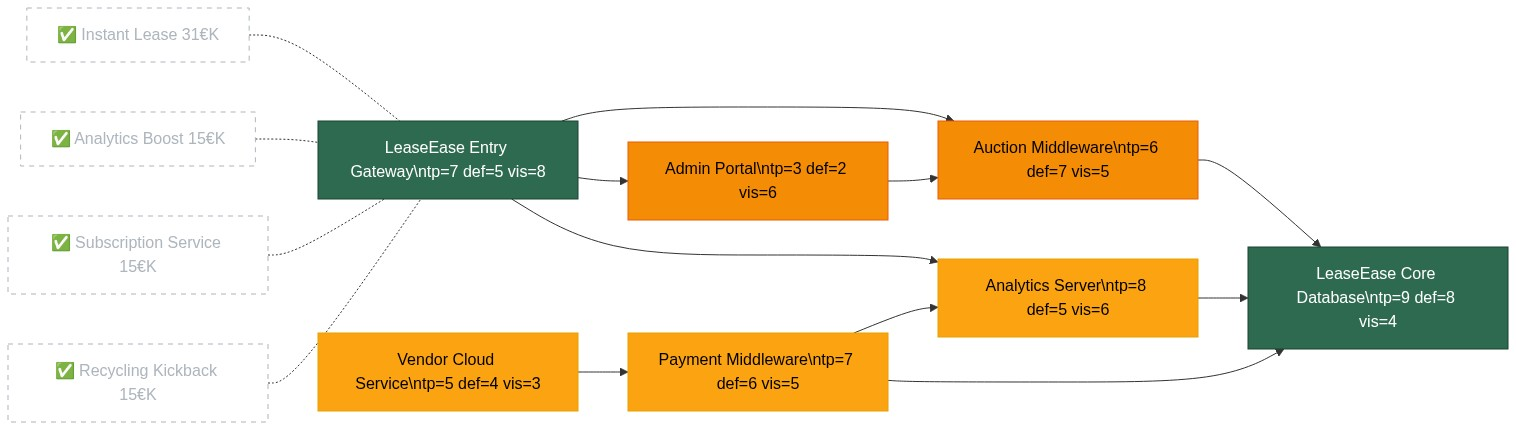

In [114]:
display(render_mermaid(gs))


In [115]:
# Test advisors + hacker on the generated state (NO CTO agent)
current_state = result["final_gamestate"]

agents_to_test = [
    ("🛡️ CISO", ciso_graph, "ciso"),
    ("⚙️ SRE",  sre_graph,  "sre"),
    ("👹 BYTE", byte_graph, "hacker"),
]

agent_recommendations = {}

print(f"=== CRISIS ANALYSIS: {current_state['company']['name'].upper()} ===")
print(f"Scenario: {current_state['company']['description']}\n")

for agent_name, graph, role in agents_to_test:
    try:
        state_output = graph.invoke({
            "game_state": current_state,
            "active_role": role
        })

        final_state = state_output[0] if isinstance(state_output, list) else state_output
        last_message = final_state["messages"][-1]
        rec = json.loads(last_message.content)

        agent_recommendations[role] = rec

        act_id = rec.get("action_id", "??")
        target = rec.get("target", "?")
        title  = rec.get("action_label", "N/A")
        desc   = rec.get("action_description", "—")
        cost   = rec.get("cost", 0)

        print(f"{agent_name} → [{act_id}] on {target} | {title} | {cost}€K")
        print(f"  {desc}")

        mutations = rec.get("mutations", [])
        if mutations:
            for m in mutations:
                print(f"  📐 {m['node_id']}.{m['attribute']} = {m['value']}")
        print("-" * 60)

    except Exception as e:
        print(f"❌ Error with {agent_name}: {e}")

print("\n💼 CTO actions available to player: C1-C6 (Report, MFA, Patch, Ransom, Evict, Do Nothing)")

last_ciso_rec = agent_recommendations.get('ciso', {'mutations': []})
last_sre_rec = agent_recommendations.get('sre', {'mutations': []})
last_byte_rec = agent_recommendations.get('hacker', {'mutations': []})

print(f"\n✅ Recommendations saved for EPIC 4 test")

=== CRISIS ANALYSIS: LEASEEASE ===
Scenario: LeaseEase is turning the snooze-fest of corporate furniture leasing into a digital adventure with questionable code but undeniable potential.

DEBUG: Role: ciso | Key Hash: -4012487775612103477
DEBUG: Score: 0.9485760927200317
💨 Cache Miss for ciso
✅ Cache saved for ciso
🛡️ CISO → [S1+S3] on n2 | Hard/Scan n2 | 130€K
  Scan for vulnerabilities and raise defense on Admin Portal (n2).
------------------------------------------------------------
DEBUG: Role: sre | Key Hash: 7725638484207505101
DEBUG: Score: 0.9498798251152039
💨 Cache Miss for sre
✅ Cache saved for sre
⚙️ SRE → [S1+S3] on n1 | Boost n1 throughput + monitor | 90€K
  Increase n1 throughput by 2 and enable monitoring for visibility.
  📐 n1.throughput = 2
  📐 n1.visibility = True
------------------------------------------------------------
DEBUG: Role: hacker | Key Hash: 6876774377041463670
DEBUG: Score: 0.9533497095108032
💨 Cache Miss for hacker
✅ Cache saved for hacker
👹 BYTE → [B

In [116]:
# ============================================================
# EPIC 4 — Resolution Engine
# ============================================================

import copy

def extract_mutations(agent_recommendation: dict) -> list:
    """
    Extract and validate mutations from agent recommendation.
    
    Validates:
    - Input is dict with 'mutations' key containing list of dicts.
    - Each mutation has required keys: 'node_id' (str), 'attribute' (str), 'value' (int/float/bool).
    - Ignores invalid entries (e.g., missing keys, wrong types).
    
    Returns list of valid mutation dicts, or empty list if invalid input.
    
    Example: extract_mutations({'mutations': [{'node_id': 'n2', 'attribute': 'defense', 'value': 3}]})
    """
    if not isinstance(agent_recommendation, dict):
        return []
    
    mutations = agent_recommendation.get('mutations', [])
    if not isinstance(mutations, list):
        return []
    
    valid_mutations = []
    for mut in mutations:
        if not isinstance(mut, dict):
            continue
        required_keys = ['node_id', 'attribute', 'value']
        if not all(key in mut for key in required_keys):
            continue
        node_id = mut['node_id']
        attribute = mut['attribute']
        value = mut['value']
        if not isinstance(node_id, str) or not isinstance(attribute, str):
            continue
        if not isinstance(value, (int, float, bool)):
            continue
        valid_mutations.append({
            'node_id': node_id,
            'attribute': attribute,
            'value': value
        })
    return valid_mutations

print("✅ extract_mutations loaded")


✅ extract_mutations loaded


In [124]:
def apply_mutations(state: dict, mutations: list) -> tuple:
    """
    Apply mutations IN-PLACE on state (no deepcopy — caller is responsible).
    Returns: (state, list_of_applied_mutations)
    """
    applied = []
    
    raw_nodes = state.get('nodes', [])
    node_map = {n['id']: n for n in raw_nodes if isinstance(n, dict) and 'id' in n}
    
    for mut in mutations:
        node_id = mut.get('node_id')
        attribute = mut.get('attribute')
        value = mut.get('value')
        
        if not node_id or not attribute or node_id not in node_map:
            continue
        
        node = node_map[node_id]
        
        # Create attribute if missing (LLM may set tags not yet present)
        if attribute not in node:
            node[attribute] = False if isinstance(value, bool) else 0
        
        old_value = node[attribute]
        
        # Convert numpy types
        if hasattr(value, 'item'):
            value = value.item()
        
        # Clamp int attributes to valid ranges
        if attribute in ('defense', 'visibility', 'cost', 'compliance_score'):
            value = int(max(0, min(10, value)))
        elif attribute == 'throughput':
            value = int(max(0, min(10, value)))
        elif isinstance(value, bool) or attribute in ('compromised', 'locked', 'offline', 'isolated', 'fogged', 'has_mfa', 'monitored', 'has_backdoor'):
            value = bool(value)
        
        node[attribute] = value
        applied.append({
            'node_id': node_id,
            'attribute': attribute,
            'old_value': old_value,
            'new_value': value
        })
    
    return state, applied

print("✅ apply_mutations loaded (in-place, no deepcopy)")

✅ apply_mutations loaded (in-place, no deepcopy)


In [125]:
def calculate_revenue(state: dict) -> dict:
    """
    GDD §10 Revenue + Cash reconciliation.
    Revenue: base × min_throughput_in_path / 10 (NOT /100).
    Costs: sum(node.cost × 5) + sum(effect.cost_per_turn).
    Cash: += total_revenue - total_costs
    Returns: {total_revenue, total_costs, net_income, cash}
    """
    company = state.get('company', {})
    nodes = state.get('nodes', [])
    node_map = {n['id']: n for n in nodes if isinstance(n, dict) and 'id' in n}
    flows = state.get('flows', [])
    effects = state.get('effects', [])

    # 1. Revenue per flow (GDD §10)
    total_revenue = 0
    for flow in flows:
        path = flow.get('node_path', [])
        if not path:
            flow['is_active'] = False
            flow['current_revenue'] = 0
            continue

        flow['is_active'] = all(
            not node_map.get(nid, {}).get('offline', False) and
            not node_map.get(nid, {}).get('locked', False) and
            not node_map.get(nid, {}).get('isolated', False)
            for nid in path
        )

        if not flow['is_active']:
            flow['current_revenue'] = 0
            continue

        throughputs = [int(node_map.get(nid, {}).get('throughput', 5)) for nid in path]
        min_tp = min(throughputs) if throughputs else 5
        base = flow.get('base_revenue', 0)
        flow['current_revenue'] = int(base * min_tp / 10)  # GDD: /10 not /100
        total_revenue += flow['current_revenue']

    # 2. Operational costs (GDD §10: cost × 5 per node per turn)
    node_costs = sum(int(n.get('cost', 0)) * 5 for n in nodes)
    effect_costs = sum(int(e.get('cost_per_turn', 0)) for e in effects)
    total_costs = node_costs + effect_costs

    # 3. Net income
    net_income = total_revenue - total_costs
    company['cash'] = max(0, int(company.get('cash', 0)) + net_income)

    return {
        'total_revenue': total_revenue,
        'total_costs': total_costs,
        'node_costs': node_costs,
        'effect_costs': effect_costs,
        'net_income': net_income,
        'cash': company['cash']
    }

print("✅ calculate_revenue loaded (GDD §10 compliant: /10, includes node costs)")

✅ calculate_revenue loaded (GDD §10 compliant: /10, includes node costs)


In [126]:
def execute_turn(state: dict, player_action_id: str, agent_recommendations: dict) -> dict:
    """
    Execute a complete turn: Tick → Byte → Regulator → Player → Revenue → Win/Lose.
    GDD §4 turn structure + §10 resolution + §12 win/lose conditions.
    
    Returns: updated state with turn_log, snapshots, game_over flag.
    """
    new_state = copy.deepcopy(state)
    company = new_state['company']
    regulator = new_state['regulator']
    nodes = new_state['nodes']
    node_map = {n['id']: n for n in nodes}

    # Normalize
    if regulator.get('breach_timer') is None:
        regulator['breach_timer'] = 0

    # ── Phase 0: TICK (GDD §4 step 1) ──
    # Decrement offline_turns, clear at 0
    for n in nodes:
        ot = n.get('offline_turns', 0)
        if ot > 0:
            n['offline_turns'] = ot - 1
            if n['offline_turns'] == 0:
                n['offline'] = False

    # Decrement temporary effects
    effects = new_state.get('effects', [])
    for e in effects:
        e['turns_remaining'] = e.get('turns_remaining', 0) - 1
    new_state['effects'] = [e for e in effects if e['turns_remaining'] > 0]

    # ── Phase 1: BYTE (GDD §4 step 2) ──
    byte_rec = agent_recommendations.get('byte', {'mutations': []})
    byte_mutations = extract_mutations(byte_rec)
    _, applied_byte = apply_mutations(new_state, byte_mutations)
    breach_occurred = len(applied_byte) > 0

    # ── Phase 2: REGULATOR (GDD §4 step 3, §6 R1-R4) ──
    turn_num = company.get('turn', 0) + 1

    # R1: Fine on breach_timer expiry
    if breach_occurred:
        regulator['breach_timer'] = regulator.get('breach_timer', 0) + 1

    if regulator['breach_timer'] > 0:
        regulator['breach_timer'] -= 1
        if regulator['breach_timer'] == 0 and not company.get('breach_reported', False):
            # Fine scales with turn: 500 + (turn * 150), cap 2000
            fine = min(2000, 500 + turn_num * 150)
            company['cash'] = max(0, company.get('cash', 0) - fine)
            company['compliance'] = max(0, company.get('compliance', 0.7) - 0.10)

    # R2: Forced audit if compliance < 0.5
    forced_audit = False
    if company.get('compliance', 0.7) < 0.5:
        forced_audit = True  # player loses their action

    # R3: Suspend node if compliance < 0.2
    if company.get('compliance', 0.7) < 0.2:
        worst = min(nodes, key=lambda n: n.get('compliance_score', 5))
        worst['offline'] = True
        worst['offline_turns'] = 3

    # R4: Deletion request at turn 6-7
    deletion_event = None
    if turn_num in (6, 7) and not regulator.get('deletion_requested'):
        regulator['deletion_requested'] = True
        deletion_event = "DELETION_REQUEST"
        # Player must choose purge or ignore — handled by frontend/next turn

    # ── Phase 3: PLAYER (GDD §4 step 5) ──
    player_mutations = []
    if not forced_audit:  # R2 blocks player action
        if player_action_id in agent_recommendations:
            player_mutations = extract_mutations(agent_recommendations[player_action_id])
        _, applied_player = apply_mutations(new_state, player_mutations)
    else:
        applied_player = []

    # ── Phase 4: REVENUE + COSTS (GDD §10) ──
    financials = calculate_revenue(new_state)

    # ── Phase 5: COMPLIANCE DRIFT (GDD §10) ──
    online_nodes = [n for n in nodes if not n.get('offline')]
    if online_nodes:
        avg_comp = sum(n.get('compliance_score', 5) for n in online_nodes) / len(online_nodes) / 10
        company['compliance'] = max(0, min(1, 
            company.get('compliance', 0.7) + (avg_comp - company.get('compliance', 0.7)) * 0.1
        ))

    # ── Phase 6: WIN/LOSE CHECK (GDD §12) ──
    company['turn'] = turn_num
    game_over = False
    game_over_reason = None

    core_db = next((n for n in nodes if n.get('type') == 'database'), None)

    if company.get('cash', 0) <= 0:
        game_over, game_over_reason = True, "💀 Faillite — cash ≤ 0"
    elif company.get('compliance', 0.7) <= 0:
        game_over, game_over_reason = True, "⚖️ Shutdown réglementaire — compliance ≤ 0"
    elif company.get('reputation', 0.8) <= 0:
        game_over, game_over_reason = True, "📉 Exode clients — reputation ≤ 0"
    elif core_db and core_db.get('locked'):
        game_over, game_over_reason = True, "🔒 Breach — Core DB locked, game over"
    elif turn_num > 10:
        if (company.get('cash', 0) > 0 and 
            company.get('compliance', 0.7) > 0.5 and 
            company.get('reputation', 0.8) > 0.3):
            game_over, game_over_reason = True, "🏆 VICTOIRE — survécu 10 tours !"
        else:
            game_over, game_over_reason = True, "❌ Défaite — survécu mais pas assez solide"

    # ── Phase 7: TURN LOG ──
    log_entry = {
        'turn': turn_num,
        'byte_mutations_applied': len(applied_byte),
        'breach_occurred': breach_occurred,
        'breach_timer': regulator['breach_timer'],
        'deletion_requested': regulator.get('deletion_requested', False),
        'deletion_event': deletion_event,
        'forced_audit': forced_audit,
        'player_action_id': player_action_id if not forced_audit else "BLOCKED_BY_AUDIT",
        'player_mutations_applied': len(applied_player),
        'financials': financials,
        'company_metrics': {
            'cash': company.get('cash', 0),
            'reputation': company.get('reputation', 0.8),
            'compliance': company.get('compliance', 0.7),
        },
        'game_over': game_over,
        'game_over_reason': game_over_reason,
    }
    new_state.setdefault('turn_log', []).append(log_entry)

    new_state.setdefault('snapshots', []).append({
        'turn': turn_num,
        'cash': company.get('cash', 0),
        'reputation': company.get('reputation', 0.8),
        'compliance': company.get('compliance', 0.7),
        'net_income': financials.get('net_income', 0),
    })

    new_state['game_over'] = game_over
    new_state['game_over_reason'] = game_over_reason

    return new_state

In [127]:
# ============================================================
# EPIC 4 — Test: Execute a Full Turn (Reusing Agent Recommendations)
# ============================================================

print("\n" + "="*60)
print("🎮 EPIC 4 TEST: Full Turn Execution")
print("="*60)

# Use game state from EPIC 3 (deep copy)
initial_state = copy.deepcopy(current_state)
print(f"\n📊 Initial State (Turn {initial_state['company']['turn']}):")
print(f"   Cash: {initial_state['company']['cash']}€K")
print(f"   Reputation: {initial_state['company']['reputation']}")
print(f"   Breach Timer: {initial_state['regulator']['breach_timer']}")

# Reuse pre-collected recommendations from previous agent tests
agent_recommendations = {
    'ciso': last_ciso_rec if 'last_ciso_rec' in locals() else {'mutations': []},
    'sre': last_sre_rec if 'last_sre_rec' in locals() else {'mutations': []},
    'hacker': last_byte_rec if 'last_byte_rec' in locals() else {'mutations': []}
}

# If recommendations not available, create empty ones
if not any(agent_recommendations.values()):
    print("\n⚠️ No pre-collected recommendations found. Using empty recommendations.")
    agent_recommendations = {'ciso': {'mutations': []}, 'sre': {'mutations': []}, 'hacker': {'mutations': []}}
else:
    print("\n✅ Using pre-collected agent recommendations")
    for role, rec in agent_recommendations.items():
        print(f"   {role}: {len(rec.get('mutations', []))} mutations")

# Map 'hacker' role to 'byte' for execute_turn
if 'hacker' in agent_recommendations:
    agent_recommendations['byte'] = agent_recommendations.pop('hacker')

# Player selects CISO recommendation
player_action_id = "ciso"
print(f"\n🎯 Player selects: {player_action_id.upper()}")

# Execute the turn
print(f"\n🔄 Executing turn...")
new_state = execute_turn(initial_state, player_action_id, agent_recommendations)

# Debug APRÈS execute_turn
print(f"DEBUG: turn = {new_state['company']['turn']}")  
print(f"DEBUG: flows active = {[f['is_active'] for f in new_state['flows']]}")
# Montrer QUEL node bloque chaque flow
node_map = {n['id']: n for n in new_state['nodes']}
for f in new_state['flows']:
    blockers = [nid for nid in f['node_path'] if node_map.get(nid, {}).get('offline') or node_map.get(nid, {}).get('locked') or node_map.get(nid, {}).get('isolated')]
    dupes = len(f['node_path']) != len(set(f['node_path']))
    print(f"  {f['name']:25s} path={f['node_path']} active={f['is_active']} blockers={blockers} dupes={dupes}")


print(f"DEBUG: new_state['company']['turn'] = {new_state['company']['turn']}")
print(f"DEBUG: flows active = {[f['is_active'] for f in new_state['flows']]}")
print(f"DEBUG: first flow path nodes exist = {[nid in {n['id'] for n in new_state['nodes']} for nid in new_state['flows'][0]['node_path']]}")

# Display results
print(f"\n📋 Turn Execution Results:")
print(f"\n   📊 Metrics Before → After:")
print(f"      Cash:       {initial_state['company']['cash']}€K → {new_state['company']['cash']}€K")
print(f"      Reputation: {initial_state['company']['reputation']} → {new_state['company']['reputation']}")
print(f"      Turn:       {initial_state['company']['turn']} → {new_state['company']['turn']}")

print(f"\n   🐛 Regulator:")
print(f"      Breach Timer: {initial_state['regulator']['breach_timer']} → {new_state['regulator']['breach_timer']}")
print(f"      Deletion Requested: {new_state['regulator'].get('deletion_requested', False)}")

# Display latest turn log entry
if new_state.get('turn_log') and len(new_state['turn_log']) > 0:
    latest = new_state['turn_log'][-1]
    print(f"\n   📝 Turn Log Entry (Turn {latest.get('turn', '?')}):")
    print(f"      Byte Mutations: {latest.get('byte_mutations_applied', 0)}")
    print(f"      Breach Occurred: {latest.get('breach_occurred', False)}")
    print(f"      Player Mutations: {latest.get('player_mutations_applied', 0)}")
    print(f"      Revenue Generated: {latest.get('revenue', 0)}€K")

print(f"\n✅ Turn Complete!")
print("="*60)

print(f"\n   💰 Financials:")
fin = latest.get('financials', {})
print(f"      Revenue:    +{fin.get('total_revenue', 0)}€K")
print(f"      Node costs: -{fin.get('node_costs', 0)}€K")
print(f"      Net income: {fin.get('net_income', 0)}€K")

# Update state for next iterations
gs = new_state



🎮 EPIC 4 TEST: Full Turn Execution

📊 Initial State (Turn 1):
   Cash: 5500€K
   Reputation: 0.8
   Breach Timer: None

✅ Using pre-collected agent recommendations
   ciso: 0 mutations
   sre: 2 mutations
   hacker: 2 mutations

🎯 Player selects: CISO

🔄 Executing turn...
DEBUG: turn = 2
DEBUG: flows active = [False, True, True, False]
  Instant Lease             path=['n1', 'n6', 'n4'] active=False blockers=['n4'] dupes=False
  Analytics Boost           path=['n1', 'n6', 'n2'] active=True blockers=[] dupes=False
  Subscription Service      path=['n1', 'n3', 'n2'] active=True blockers=[] dupes=False
  Recycling Kickback        path=['n1', 'n2', 'n4'] active=False blockers=['n4'] dupes=False
DEBUG: new_state['company']['turn'] = 2
DEBUG: flows active = [False, True, True, False]
DEBUG: first flow path nodes exist = [True, True, True]

📋 Turn Execution Results:

   📊 Metrics Before → After:
      Cash:       5500€K → 4580€K
      Reputation: 0.8 → 0.8
      Turn:       1 → 2

   🐛 Regul